**1. Introduction & Problem Statement**
Problem: High customer turnover (churn) reduces bank profitability and increases acquisition costs.

Objective: Build a predictive system to identify "high-risk" customers before they leave, allowing the bank to take proactive retention steps.

**2. Dataset Understanding**
Source: Churn Modelling Dataset (10,000 records).

Target: Exited (1 = Left, 0 = Stayed).

Features: Financial data (Credit Score, Balance, Salary) and Demographics (Age, Gender, Geography).

Cleaning: Dropped non-predictive identifiers (RowNumber, CustomerId, Surname) to reduce noise.

In [1]:
import pandas as pd

# Load the dataset from your uploaded file
df = pd.read_csv('churn.csv')

# 1. See the first 5 rows to understand the columns
print("--- Dataset Head ---")
display(df.head())

# 2. Check for data types and missing values
print("\n--- Dataset Info ---")
df.info()

--- Dataset Head ---


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [2]:
# Drop columns that don't help with prediction
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# Display the new list of columns to confirm
print("Remaining Columns:")
print(df.columns.tolist())

# Show the first 2 rows of the cleaned data
df.head(2)

Remaining Columns:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0


In [3]:
from sklearn.preprocessing import LabelEncoder

# 1. Label Encoding for Gender (Male/Female -> 0/1)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# 2. One-Hot Encoding for Geography (France, Spain, Germany)
# This creates new columns: Geography_Germany, Geography_Spain, etc.
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

# Display the first few rows to see the transformation
print("Encoded Dataset:")
df.head()

Encoded Dataset:


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate Features (X) and Target (y)
X = df.drop('Exited', axis=1)  # All columns except the one we want to predict
y = df['Exited']              # The 'Exited' column is our target

# 2. Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the features
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

print("Data successfully split and scaled!")
print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows: {X_test.shape[0]}")

Data successfully split and scaled!
Training rows: 8000
Testing rows: 2000


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# 1. Initialize the Random Forest Classifier
# n_estimators=100 means we are using 100 individual decision trees
classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model using our scaled training data
classifier.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred = classifier.predict(X_test)

# 4. Evaluate the performance
print("--- Model Accuracy ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Model Accuracy ---
Accuracy Score: 86.65%

--- Confusion Matrix ---
[[1551   56]
 [ 211  182]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.76      0.46      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



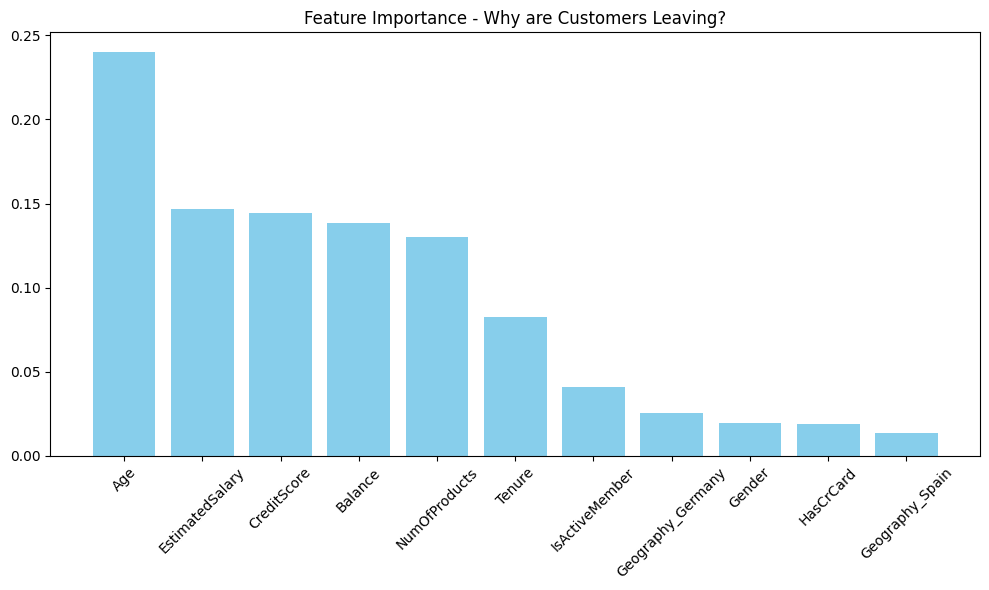

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Get the feature importance from our trained model
importances = classifier.feature_importances_
feature_names = X.columns

# 2. Sort the features by importance
indices = np.argsort(importances)[::-1]

# 3. Plot the feature importance
plt.figure(figsize=(10, 6))
plt.title("Feature Importance - Why are Customers Leaving?")
plt.bar(range(X.shape[1]), importances[indices], align="center", color='skyblue')
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

In [7]:
import numpy as np

# --- 1. PREDICTING A FAKE CUSTOMER ---
# Imagine a 50-year-old customer from Germany with a high balance and 1 product.
# We must follow the EXACT column order of X (the dataframe before scaling).
# Order: CreditScore, Gender, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, Geography_Germany, Geography_Spain

fake_customer = [[600, 1, 50, 3, 60000, 1, 1, 1, 50000, 1, 0]] # 1 = Male, 1 = Germany

# Scale the fake customer data
fake_customer_scaled = sc.transform(fake_customer)

# Make prediction
prediction_fake = classifier.predict(fake_customer_scaled)
probability_fake = classifier.predict_proba(fake_customer_scaled)

print(f"--- Fake Customer Prediction ---")
print(f"Result: {'Will Leave' if prediction_fake[0] == 1 else 'Will Stay'}")
print(f"Confidence: {np.max(probability_fake) * 100:.2f}%")


# --- 2. PREDICTING AN ACTUAL CUSTOMER FROM TEST SET ---
# Let's grab the very first customer from your test set to see if we get it right.
actual_customer_scaled = X_test[0].reshape(1, -1)
actual_prediction = classifier.predict(actual_customer_scaled)
actual_truth = y_test.iloc[0]

print(f"\n--- Actual Customer Prediction (Test Set Row 0) ---")
print(f"Model Predicted: {'Will Leave' if actual_prediction[0] == 1 else 'Will Stay'}")
print(f"Actual Truth: {'Left' if actual_truth == 1 else 'Stayed'}")
print(f"Correct? {'YES' if actual_prediction[0] == actual_truth else 'NO'}")

--- Fake Customer Prediction ---
Result: Will Stay
Confidence: 58.00%

--- Actual Customer Prediction (Test Set Row 0) ---
Model Predicted: Will Stay
Actual Truth: Stayed
Correct? YES


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
